In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
def get_cutflow_and_yields_for_run_range(files, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    run = os.path.basename(files[0]).split('.')[0]

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            total_lumi += lumi[0] / 1000 # /pb -> /fb
            for idx, row in df.iterrows():
                cut = row["cut_name"]
                all = row["all"]
                passed = row["passed"]
        
                if cut not in cutflow_dict:
                    cutflow_dict[cut] = {"all": 0, "passed": 0}
        
                cutflow_dict[cut]["all"] += all
                cutflow_dict[cut]["passed"] += passed
                cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[run] = final_yield
                
    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [3]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

In [18]:
cutflow_F222, yields_F222 = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_F223, yields_F223 = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_F231, yields_F231 = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_F232, yields_F232 = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_F241, yields_F241         = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2024_noCaloNu_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_tungsten, yields_tungsten = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2024_noCaloNu_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_F242, yields_F242         = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2024_noCaloNu_FTFP_BERT_HP_JEFF33.bck.root"])
cutflow_caloNu, yields_caloNu     = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2024_CaloNu_FTFP_BERT_HP_JEFF33.bck.root"], mass=0.68)
cutflow_F243, yields_F243         = get_cutflow_and_yields_for_run_range(["build/MC_truth_cuts_more_hists/2024_noCaloNu_FTFP_BERT_HP_JEFF33.bck.root"])

100%|██████████| 1/1 [00:00<00:00, 44.62it/s]


In [19]:
print("Cutflow for F222:")
display(cutflow_F222)
print("\n")
print("Cutflow for F223:")
display(cutflow_F223)
print("\n")
print("Cutflow for F231:")
display(cutflow_F231)
print("\n")
print("Cutflow for F232:")
display(cutflow_F232)
print("\n")
print("Cutflow for F241:")
display(cutflow_F241)
print("\n")
print("Cutflow for Tungsten:")
display(cutflow_tungsten)
print("\n")
print("Cutflow for F242:")
display(cutflow_F242)
print("\n")
print("Cutflow for CaloNu:")
display(cutflow_caloNu)
print("\n")
print("Cutflow for F243:")
display(cutflow_F243)

Cutflow for F222:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Remove CaloNu PMT region (truth),1493362,1493362,1.000000,1.000000,0.000000,0
CC events only,1493362,1132076,0.758072,0.758072,0.000350,0
nu_mu only,1132076,940528,0.830799,0.629806,0.000352,0
In Faser Nu Box or Lead Block,940528,395120,0.420104,0.264584,0.000509,0
Truth dec r < 100 mm,395120,182415,0.461670,0.122151,0.000793,0
Truth pz > 100 GeV,182415,168689,0.924754,0.112959,0.000618,0
At least one long track,168689,93953,0.556960,0.062914,0.001209,0
VetoNu0 reduced charge < 30 pC,93953,84464,0.899003,0.056560,0.000983,0
VetoNu1 reduced charge < 30 pC,84464,81009,0.959095,0.054246,0.000682,0
Veto20 and Veto21 charge > 40 pC,81009,80953,0.999309,0.054209,0.000092,0




Cutflow for F223:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Remove CaloNu PMT region (truth),1493362,1493362,1.000000,1.000000,0.000000,0
CC events only,1493362,1132076,0.758072,0.758072,0.000350,0
nu_mu only,1132076,940528,0.830799,0.629806,0.000352,0
In Faser Nu Box or Lead Block,940528,395120,0.420104,0.264584,0.000509,0
Truth dec r < 100 mm,395120,182415,0.461670,0.122151,0.000793,0
Truth pz > 100 GeV,182415,168689,0.924754,0.112959,0.000618,0
At least one long track,168689,93953,0.556960,0.062914,0.001209,0
VetoNu0 reduced charge < 30 pC,93953,84464,0.899003,0.056560,0.000983,0
VetoNu1 reduced charge < 30 pC,84464,81009,0.959095,0.054246,0.000682,0
Veto20 and Veto21 charge > 40 pC,81009,80953,0.999309,0.054209,0.000092,0




Cutflow for F231:


...

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Remove CaloNu PMT region (truth),1450841,1450841,1.000000,1.000000,0.000000,0
CC events only,1450841,1100511,0.758533,0.758533,0.000355,0
nu_mu only,1100511,918140,0.834285,0.632833,0.000354,0
In Faser Nu Box or Lead Block,918140,367171,0.399907,0.253075,0.000511,0
Truth dec r < 100 mm,367171,177850,0.484379,0.122584,0.000825,0
Truth pz > 100 GeV,177850,164274,0.923666,0.113227,0.000630,0
At least one long track,164274,91011,0.554020,0.062730,0.001226,0
VetoNu0 reduced charge < 30 pC,91011,81849,0.899331,0.056415,0.000997,0
VetoNu1 reduced charge < 30 pC,81849,78534,0.959499,0.054130,0.000689,0
Veto20 and Veto21 charge > 40 pC,78534,78478,0.999287,0.054091,0.000095,0




Cutflow for CaloNu:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Remove CaloNu PMT region (truth),1235762,1232318,0.997213,0.997213,0.000047,0
CC events only,1232318,933826,0.757780,0.755668,0.000386,0
nu_mu only,933826,778913,0.834109,0.630310,0.000385,0
In Faser Nu Box or Lead Block,778913,234700,0.301317,0.189923,0.000520,0
Truth dec r < 100 mm,234700,114326,0.487115,0.092515,0.001032,0
Truth pz > 100 GeV,114326,105562,0.923342,0.085423,0.000787,0
At least one long track,105562,56960,0.539588,0.046093,0.001534,0
VetoNu0 reduced charge < 30 pC,56960,47363,0.831513,0.038327,0.001568,0
VetoNu1 reduced charge < 30 pC,47363,45879,0.968668,0.037126,0.000801,0
Veto20 and Veto21 charge > 40 pC,45879,45850,0.999368,0.037103,0.000117,0




Cutflow for F243:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Remove CaloNu PMT region (truth),1450841,1450841,1.000000,1.000000,0.000000,0
CC events only,1450841,1100511,0.758533,0.758533,0.000355,0
nu_mu only,1100511,918140,0.834285,0.632833,0.000354,0
In Faser Nu Box or Lead Block,918140,367171,0.399907,0.253075,0.000511,0
Truth dec r < 100 mm,367171,177850,0.484379,0.122584,0.000825,0
Truth pz > 100 GeV,177850,164274,0.923666,0.113227,0.000630,0
At least one long track,164274,91011,0.554020,0.062730,0.001226,0
VetoNu0 reduced charge < 30 pC,91011,81849,0.899331,0.056415,0.000997,0
VetoNu1 reduced charge < 30 pC,81849,78534,0.959499,0.054130,0.000689,0
Veto20 and Veto21 charge > 40 pC,78534,78478,0.999287,0.054091,0.000095,0


In [20]:
def wrap_math_text(s, caption="My table"):
    s = s.replace(r"\begin{table}", "")
    s = s.replace(r"\end{table}", "")
    s = s.replace(r"<", r"$<$").replace(r">", r"$>$").replace("=", r"$=$").replace("+", r"$+$").replace("-", r"$-$").replace("*", r"$*$").replace("/", r"$/$").replace("<=", r"$\leq$").replace(">=", r"$\geq$").replace("!=", r"$\neq$")
    s = rf"""
\begin{{table}}
\centering
\caption{{{caption}}}
\begin{{adjustbox}}{{max width=\textwidth}}
{s}
\end{{adjustbox}}
\end{{table}}
"""
    return s

In [21]:
with open("cutflows_all_periods.tex", 'w') as f:

    longtable = False
    float_format = "{:0.2f}".format
    colums = ["passed", "efficiency", "cumulative_efficiency", "rate [events/fb/tonne]"]

    f.write(r"\documentclass{article}" + "\n")
    f.write(r"\usepackage{graphicx}" + "\n")
    f.write(r"\usepackage{booktabs}" + "\n")
    f.write(r"\usepackage{longtable}" + "\n")
    f.write(r"\usepackage{adjustbox}" + "\n")
    f.write(r"\begin{document}" + "\n")
    t = wrap_math_text(cutflow_F222.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F222")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F223.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F223")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F231.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F231")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F232.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F232")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F241.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F241")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_tungsten.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for tungsten")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F242.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F242")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_caloNu.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for caloNu")
    f.write(t + "\n")
    t = wrap_math_text(cutflow_F243.to_latex(escape=True, columns=colums, longtable=longtable, float_format=float_format), caption="Cutflow for F243")
    f.write(t + "\n")
    f.write(r"\end{document}" + "\n") 


In [22]:
# with open("cutflows_all_periods.tex", 'w') as f:
#     # \documentclass{article}
#     # \usepackage{graphicx} % Required for inserting images
#     # \usepackage{booktabs}
#     # \begin{document}
#     longtable = False
#     f.write(r"\documentclass{article}" + "\n")
#     f.write(r"\usepackage{graphicx}" + "\n")
#     f.write(r"\usepackage{booktabs}" + "\n")
#     f.write(r"\usepackage{longtable}" + "\n")
#     f.wr
#     f.write(r"\begin{document}" + "\n")
#     t = wrap_math_text(cutflow_F222.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F222", label="tab:cutflow_F222", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F223.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F223", label="tab:cutflow_F223", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F231.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F231", label="tab:cutflow_F231", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F232.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F232", label="tab:cutflow_F232", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F241.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F241", label="tab:cutflow_F241", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_tungsten.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for Tungsten", label="tab:cutflow_tungsten", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F242.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F242", label="tab:cutflow_F242", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_caloNu.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for CaloNu", label="tab:cutflow_caloNu", longtable=longtable))
#     f.write(t + "\n")
#     t = wrap_math_text(cutflow_F243.to_latex(escape=True, columns=["passed", "efficiency", "cumulative_efficiency"], caption="Cutflow for F243", label="tab:cutflow_F243", longtable=longtable))
#     f.write(t + "\n")
#     f.write(r"\end{document}" + "\n") 


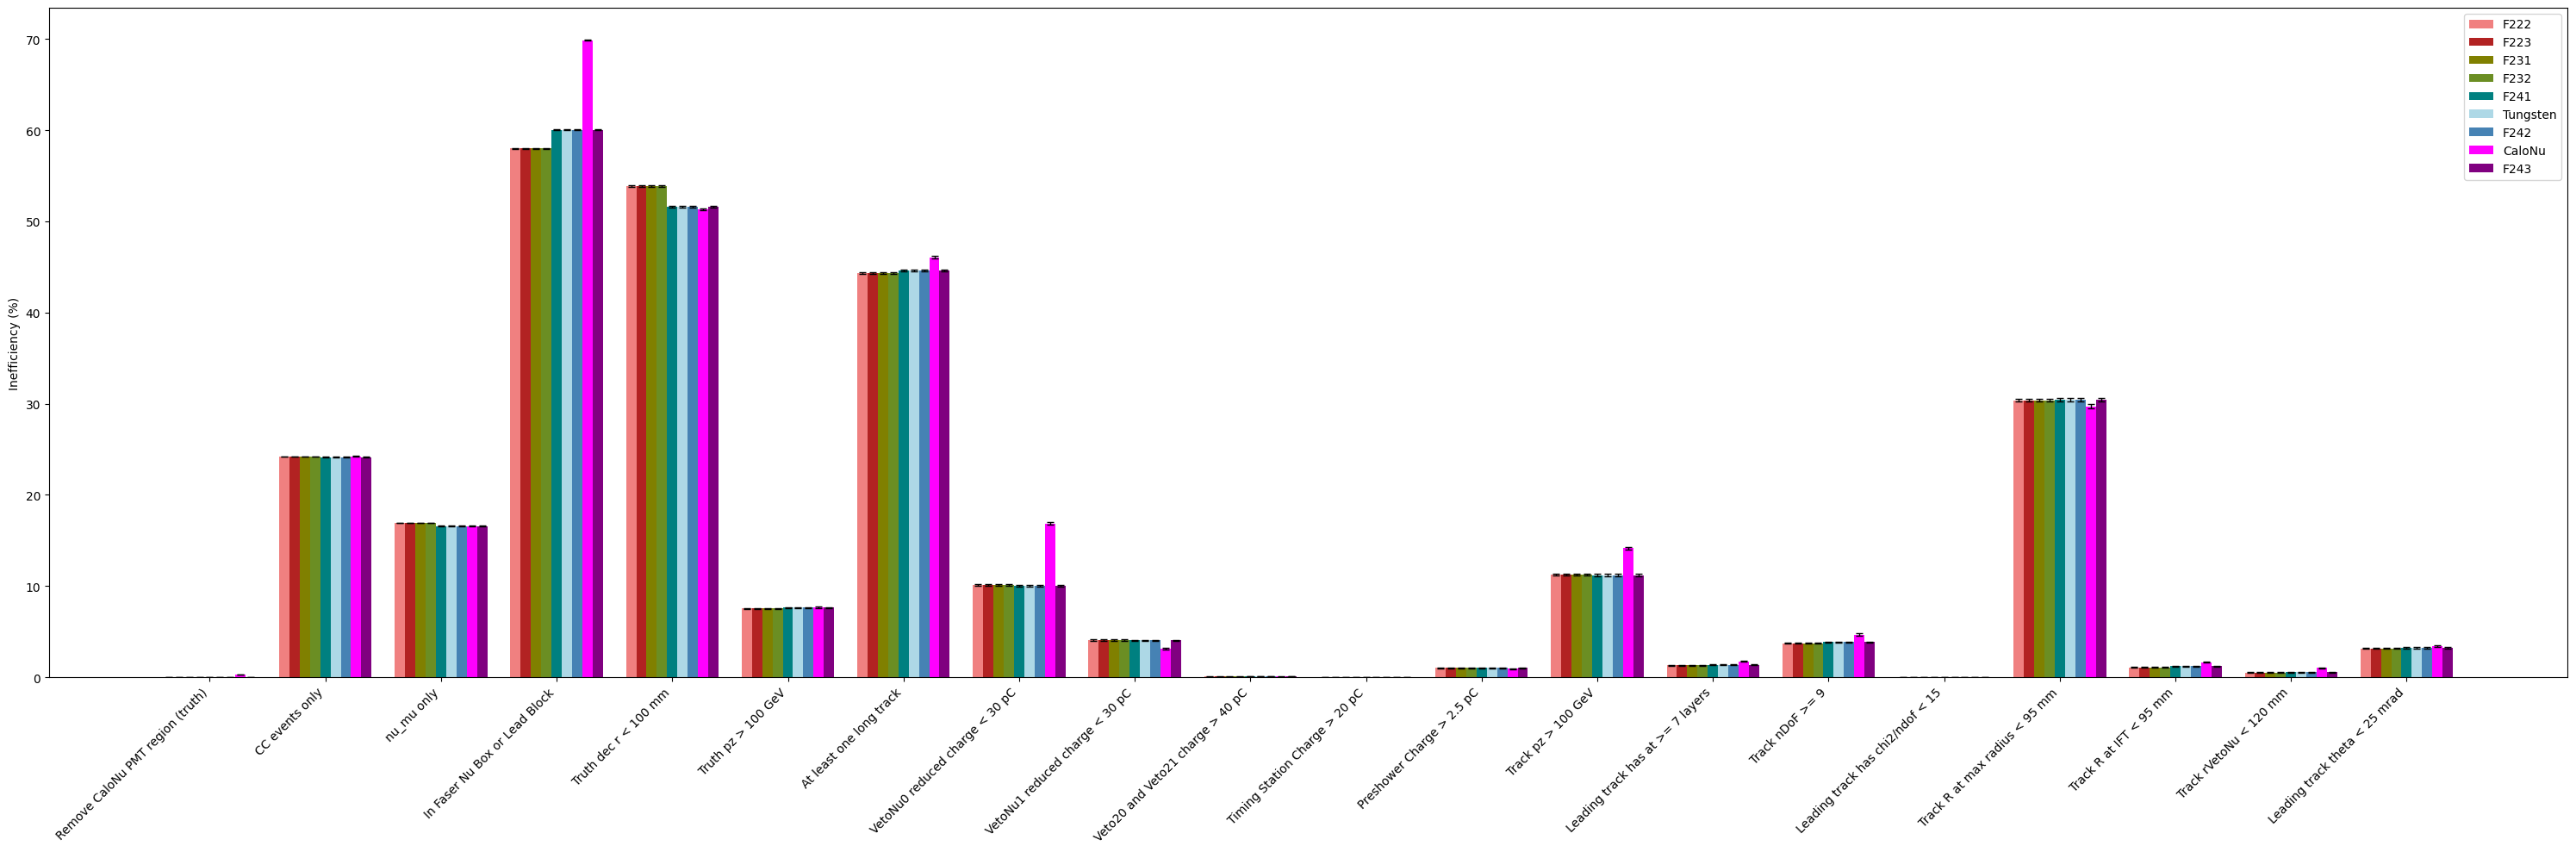

In [23]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
colours = ["lightcoral", "firebrick", "olive", "olivedrab", "teal", "lightblue", "steelblue", "magenta", "purple"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        100 - df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        100 - df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Inefficiency (%)")

plt.tight_layout()
plt.savefig("cutflow_inefficiency_comparison.png", dpi=300)
plt.show()

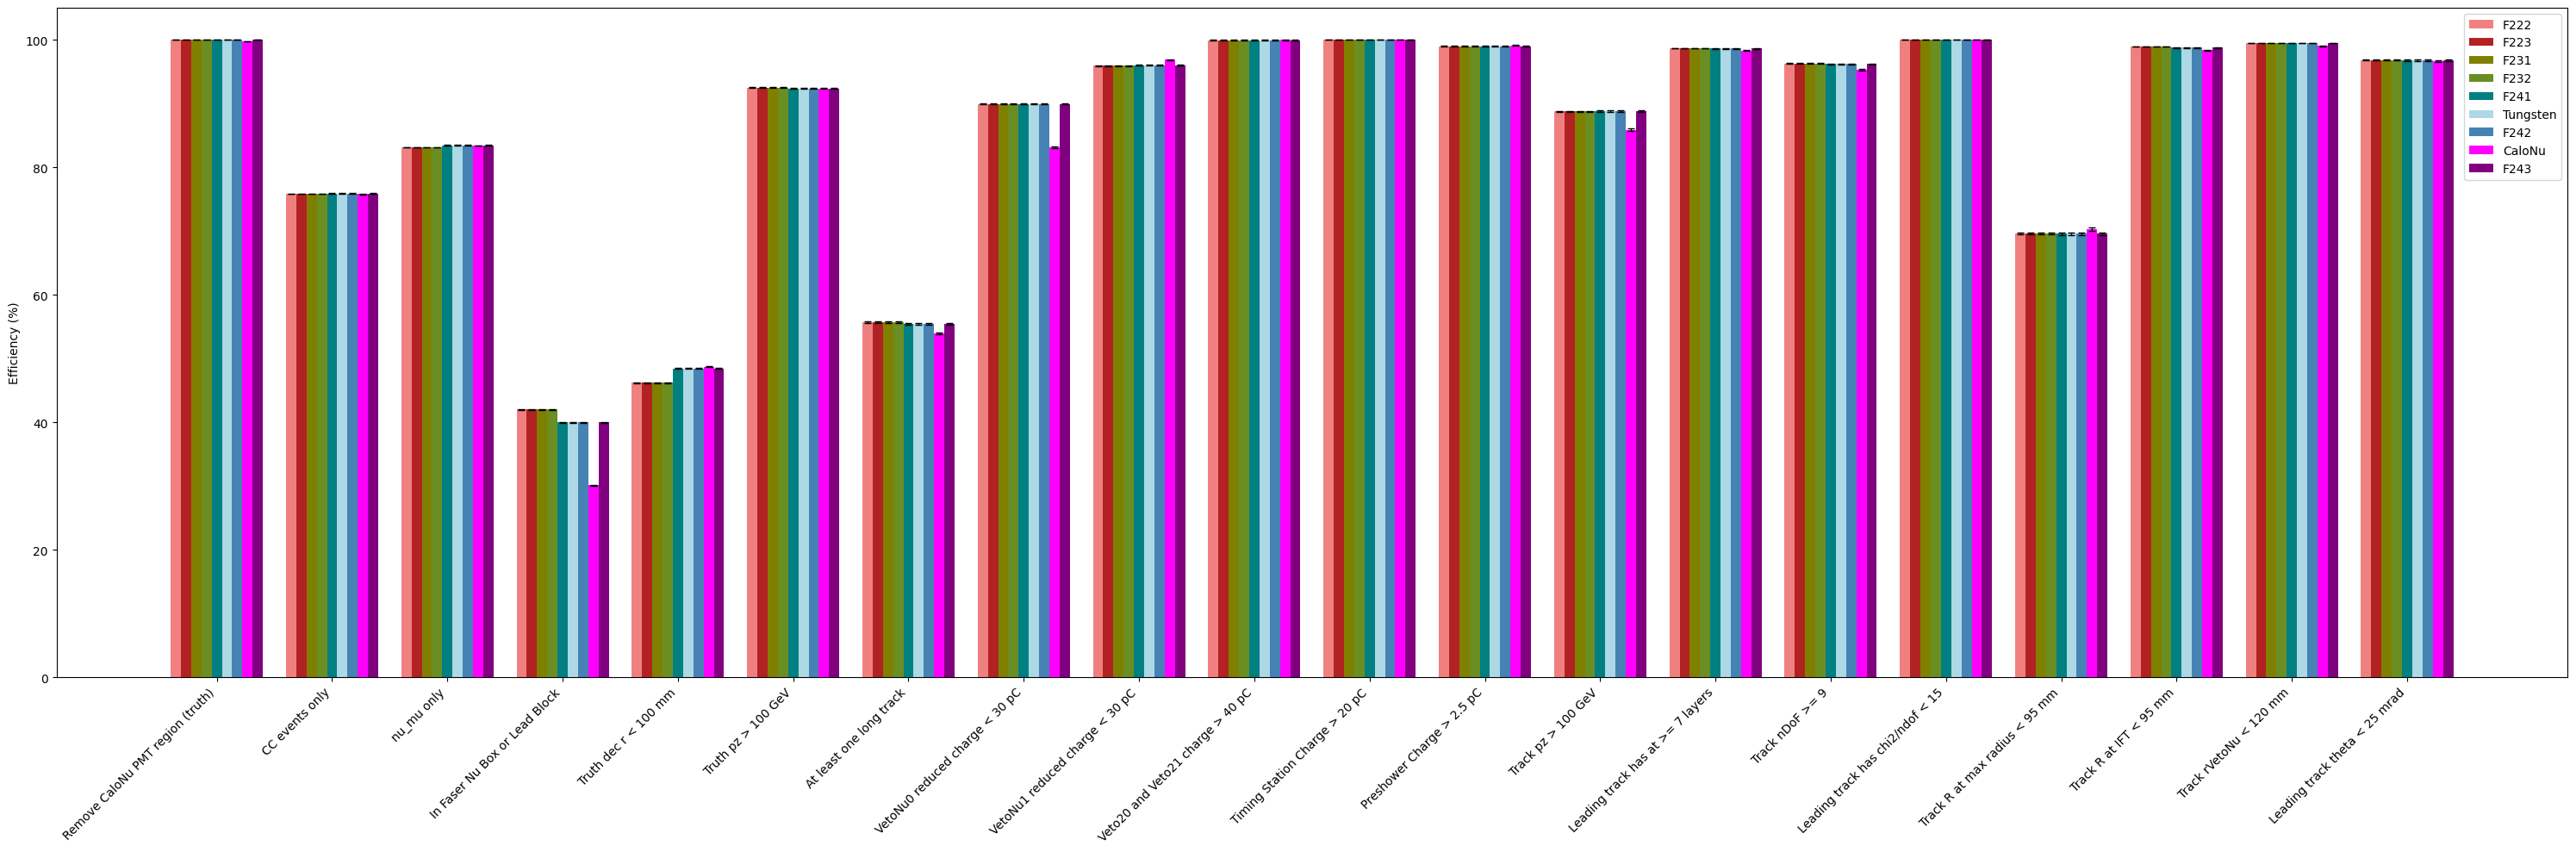

In [24]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Efficiency (%)")
# ax.set_yscale("log")

plt.tight_layout()
plt.savefig("cutflow_efficiency_comparison.png", dpi=300)
plt.show()

In [25]:
data = uproot.open("/home/ppd/bewilson/work/nuAnalysis/AnalysisZipFramework/submission/analysis_output/17023.root")
print(data.keys())
evt_idpass = data["eventID_pass"].arrays(library="pd")

['nt;1', 'meta;1', 'cutflow;1', 'eventID_pass;2']


In [26]:
display(evt_idpass)

,passed_Colliding,passed_Trigger,passed_Good_times,passed_Excluded_times,passed_Sanity_cut_to_remove_events_with_missing_aux_data,passed_VetoNu0_reduced_charge_lt_30_pC,passed_VetoNu1_reduced_charge_lt_30_pC,passed_VetoNu0_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_VetoNu1_raw_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_CaloNu_status_cleaning,...,passed_Track_pz_gt_100_GeV,passed_Leading_track_has_at_geq_7_layers,passed_Track_nDoF_geq_9,passed_Leading_track_has_chi2_ndof_lt_15,passed_Track_R_at_max_radius_lt_95_mm,passed_Track_R_at_IFT_lt_95_mm,passed_Track_rVetoNu_lt_120_mm,passed_Leading_track_theta_lt_25_mrad,run,eventID
0,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,17023,811565
1,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,False,False,False,True,17023,811568
2,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,True,False,True,True,17023,811571
3,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,False,True,True,17023,811580
4,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,False,False,True,17023,811594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14301648,True,True,True,True,True,False,False,True,True,True,...,True,True,False,True,True,True,True,True,17023,92437830
14301649,True,True,True,True,True,False,False,True,True,True,...,False,True,True,True,False,False,False,True,17023,92437832
14301650,False,False,True,True,True,True,True,True,True,True,...,False,False,False,False,True,False,False,True,17023,92437834
14301651,True,True,True,True,True,False,False,True,True,True,...,True,True,True,True,False,True,True,True,17023,92437844


In [27]:
def get_pass_fail_counts_for_run_range(files):
    pass_fail_counts = {}

    run = os.path.basename(files[0]).split('.')[0]

    for fpath in tqdm.tqdm(files):


        with uproot.open(fpath) as f:
            tree = f["eventID_pass"]
            df = tree.arrays(library="pd")

        
            for key in df.columns:

                if "passed" not in key.lower(): continue
                
                if key not in pass_fail_counts:
                    pass_fail_counts[key] = {"pass": 0, "fail": 0}
                
                pass_fail_counts[key]["pass"] += df[key].sum()
                pass_fail_counts[key]["fail"] += len(df) - df[key].sum()

        pass_fail_counts_df = pd.DataFrame.from_dict(pass_fail_counts, orient="index")   
        # pass_fail_counts_df = pass_fail_counts_df.sort_values(by='pass', ascending=False)
        
    return pass_fail_counts_df

In [28]:
pass_fail_counts_F222 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2022_2023.bck.root"])
pass_fail_counts_F223 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2022_2023.bck.root"])
pass_fail_counts_F231 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2022_2023.bck.root"])
pass_fail_counts_F232 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2022_2023.bck.root"])
pass_fail_counts_F241 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2024_noCaloNu.bck.root"])
pass_fail_counts_tungsten = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2024_noCaloNu.bck.root"])
pass_fail_counts_F242 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2024_noCaloNu.bck.root"])
pass_fail_counts_caloNu = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2024_CaloNu.bck.root"])
pass_fail_counts_F243 = get_pass_fail_counts_for_run_range(["build/MC_no_truth_cuts/2024_noCaloNu.bck.root"])

100%|██████████| 1/1 [00:00<00:00,  4.81it/s]


In [29]:
display(pass_fail_counts_F222)

,pass,fail
passed_VetoNu0_reduced_charge_lt_30_pC,1401870,91492
passed_VetoNu1_reduced_charge_lt_30_pC,1389075,104287
passed_Veto20_and_Veto21_charge_gt_40_pC,585881,907481
passed_Timing_Station_Charge_gt_20_pC,866690,626672
passed_Preshower_Charge_gt_2_5_pC,794410,698952
passed_At_least_one_long_track,213156,1280206
passed_Track_pz_gt_100_GeV,165631,1327731
passed_Leading_track_has_at_geq_7_layers,202496,1290866
passed_Track_nDoF_geq_9,190408,1302954
passed_Leading_track_has_chi2_ndof_lt_15,208941,1284421


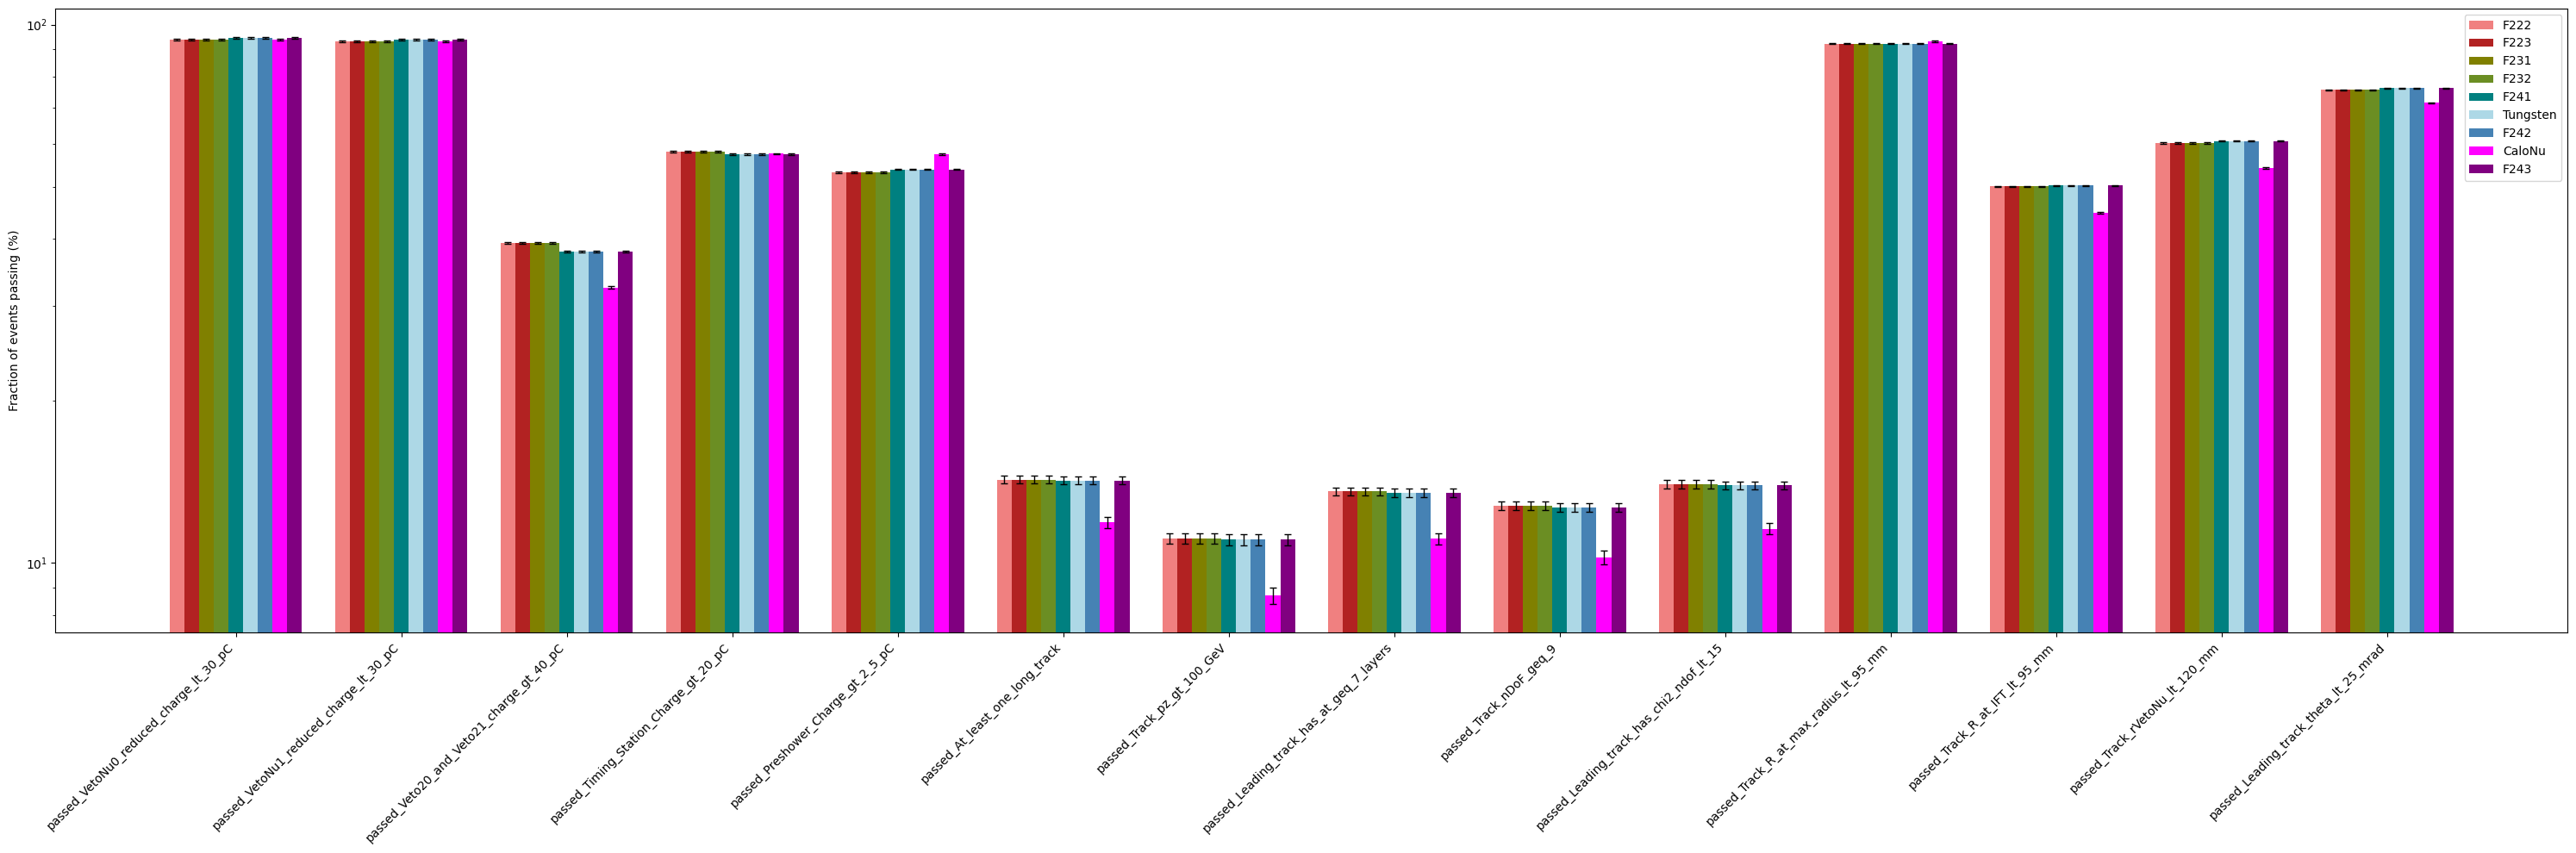

In [30]:
dfs = [pass_fail_counts_F222, pass_fail_counts_F223, pass_fail_counts_F231, pass_fail_counts_F232, pass_fail_counts_F241, pass_fail_counts_tungsten, pass_fail_counts_F242, pass_fail_counts_caloNu, pass_fail_counts_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):

    n_pass = df["pass"]
    n_fail = df["fail"]
    n_tot = n_pass + n_fail
    
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["pass"] / (df["pass"] + df["fail"]) * 100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["pass"] / (df["pass"] + df["fail"]) * 100,
        yerr=np.sqrt(1/df["pass"] + 1/df["fail"]) * 100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Fraction of events passing (%)")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("cutflow_pass_comparison.png", dpi=300)
plt.show()

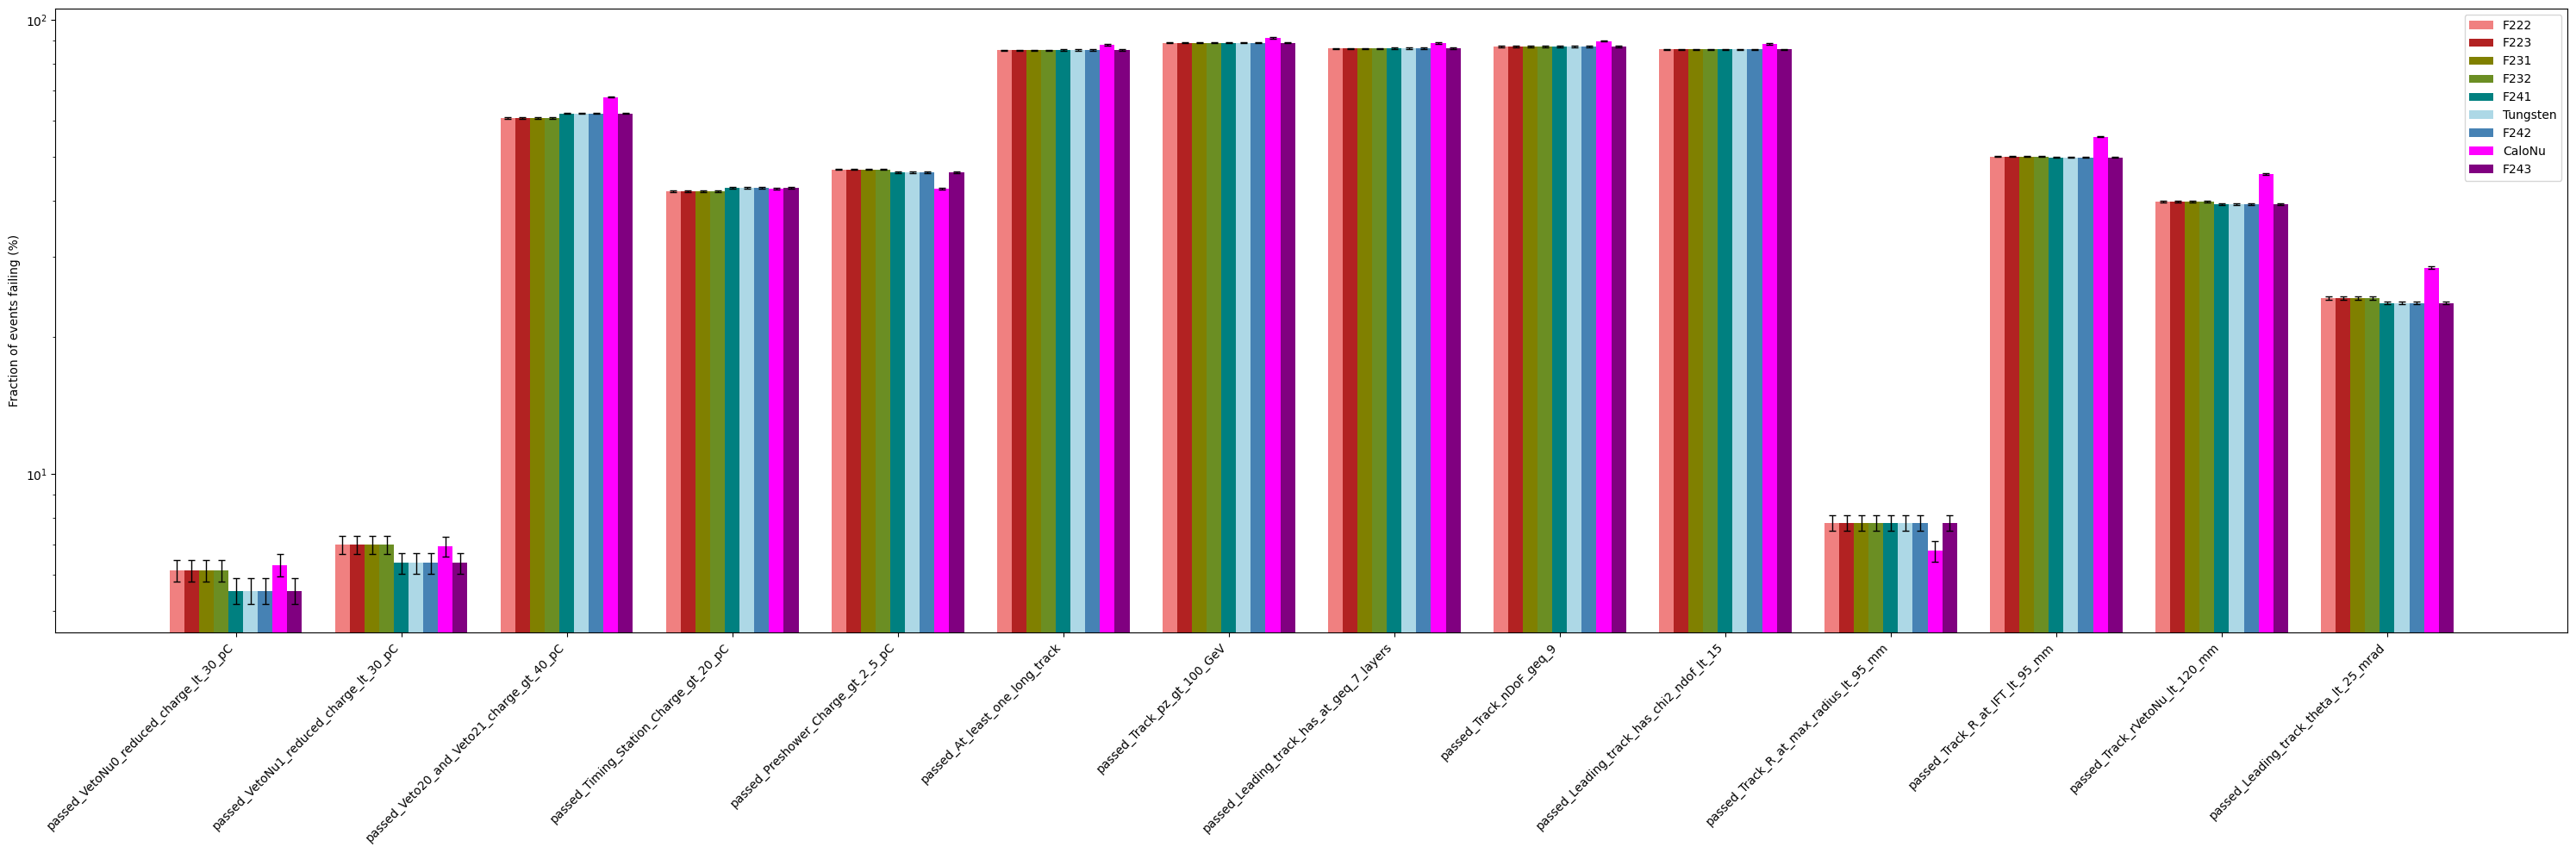

In [31]:
dfs = [pass_fail_counts_F222, pass_fail_counts_F223, pass_fail_counts_F231, pass_fail_counts_F232, pass_fail_counts_F241, pass_fail_counts_tungsten, pass_fail_counts_F242, pass_fail_counts_caloNu, pass_fail_counts_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):

    n_pass = df["pass"]
    n_fail = df["fail"]
    n_tot = n_pass + n_fail
    
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["fail"] / (df["pass"] + df["fail"]) * 100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["fail"] / (df["pass"] + df["fail"]) * 100,
        yerr=np.sqrt(1/df["pass"] + 1/df["fail"]) * 100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Fraction of events failing (%)")
ax.set_yscale("log")
# ax.set_ylim(1e-12, 1e3)
plt.savefig("cutflow_fail_comparison_log.png", dpi=300)
plt.tight_layout()
plt.show()

In [51]:
n_events_jeff33_raw = uproot.open("build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_JEFF33.bck.root:nt").num_entries
n_events_endfb8_raw = uproot.open("build/MC_truth_cuts_more_hists/2022_2023_FTFP_BERT_HP_ENDFB8.bck.root:nt").num_entries
n_events_nom_raw = uproot.open("build/MC_truth_cuts_more_hists/2022_2023.bck.root:nt").num_entries


In [52]:
n_events_jeff33_exp =( n_events_jeff33_raw / 10_000) * (36.55 + 29.7)
n_events_endfb8_exp =( n_events_endfb8_raw / 10_000) * (36.55 + 29.7)
n_events_nom_exp =( n_events_nom_raw / 10_000) * (36.55 + 29.7)

In [50]:
print(f"Expected number of events for JEFF33: {n_events_jeff33_exp:.2f}")
print(f"Expected number of events for ENDFB8: {n_events_endfb8_exp:.2f}")
print(f"Ratio of expected events (JEFF33 / ENDFB8): {n_events_jeff33_exp / n_events_endfb8_exp:.2f}")
print(f"Difference in expected events: {abs(n_events_jeff33_exp - n_events_endfb8_exp):.2f}")

Expected number of events for JEFF33: 296.64
Expected number of events for ENDFB8: 345.60
Ratio of expected events (JEFF33 / ENDFB8): 0.86
Difference in expected events: 48.96


In [53]:
print(f"Expected number of events for Nominal: {n_events_nom_exp:.2f}")
print(f"Expected number of events for ENDFB8: {n_events_endfb8_exp:.2f}")
print(f"Ratio of expected events (Nominal / ENDFB8): {n_events_nom_exp / n_events_endfb8_exp:.2f}")
print(f"Difference in expected events: {abs(n_events_nom_exp - n_events_endfb8_exp):.2f}")

Expected number of events for Nominal: 297.99
Expected number of events for ENDFB8: 345.60
Ratio of expected events (Nominal / ENDFB8): 0.86
Difference in expected events: 47.61
